# Unseen Set Testing
Having trained on some amount of sets, see what percent of an unseen set needs to be seen to achieve solid accuracy


In [21]:
# Imports

import sys
import os
sys.path.append(os.path.abspath('..'))
from venus_ml import VenusDataset

In [22]:
def get_features(names, mean=True, std=False):
    out_list = []
    for name in names:
        if mean:
            out_list.append(name + "_mean")
        if std:
            out_list.append(name + "_std")
    return out_list

requested_dict = {
    'k18_fw_mean': [1.4e3, 'Watts'],
    'g28_fw_mean': [4.3e3, 'Watts'],
    'inj_i_mean': [185, 'Amps'],
    'ext_i_mean': [137, 'Amps'],
    'mid_i_mean': [153, 'Amps'],
    'sext_i_mean': [430, 'Amps'],
    'extraction_v_mean': [20, 'kV'],
    'puller_v_mean': [2, 'kV'],
}

requested_features = list(requested_dict.keys())

feature_groups = {
    "S": ["inj_mbar", "bias_v", "bias_i", "extraction_i"],
    "M": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i"],
    "L": ["inj_mbar", "bias_v", "bias_i", "extraction_i", "ext_mbar", "k18_fw", "k18_ref", "g28_fw", "puller_i", "inj_i", "ext_i", "mid_i", "sext_i", "x_ray_source", "x_ray_exit"],
}

train_features = ["inj_mbar_mean", "bias_v_mean", "bias_i_mean", "extraction_i_mean", "ext_mbar_mean", "k18_fw_mean", "k18_ref_mean", "g28_fw_mean", "puller_i_mean", "inj_i_mean", "ext_i_mean", "mid_i_mean", "sext_i_mean", "x_ray_source_mean", "x_ray_exit_mean"]

In [23]:
config = {
    "file_path": "../data/acc_watch_data.parquet",
    "input_columns": [],
    "output_columns": [],
}



dataset = VenusDataset(**config)

# Helpers

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

def train_rf_with_unseen_percentages(df, train_run_ids, unseen_run_id, training_percentages, feature_columns, target_column, run_id_column='run_id'):
    """
    Trains a Random Forest regressor on training sets and varying percentages of an unseen set.
    Returns a tuple of R² scores, MSE errors, and training percentages.

    Parameters:
    df (DataFrame): The dataset containing features, target, and run_id columns.
    train_run_ids (list): List of run_id values to include in training data.
    unseen_run_id: The run_id value of the unseen set.
    training_percentages (list): List of percentages of unseen set to include in training.
    feature_columns (list): List of feature column names.
    target_column (str): Name of the target variable column.
    run_id_column (str): Name of the run_id column.

    Returns:
    tuple: (r2_scores, mse_errors, valid_percentages)
    """
    r2_scores = []
    mse_errors = []
    valid_percentages = []

    # Split the data into training and unseen sets based on run_id
    train_data = df[df[run_id_column].isin(train_run_ids)]
    unseen_data = df[df[run_id_column] == unseen_run_id]

    for p in training_percentages:
        if p < 0 or p > 100:
            continue  # Skip invalid percentages

        if p == 100:
            # Use all unseen data in training, no data left for testing
            training_df = pd.concat([train_data, unseen_data])
            test_df = unseen_data.sample(n=0)  # Empty test set
        elif p == 0:
            training_df = train_data
            test_df = unseen_data
        else:
            # Calculate test size based on the training percentage
            test_size = 1 - p / 100
            # Split the unseen data into training and testing subsets
            train_unseen, test_unseen = train_test_split(
                unseen_data, test_size=test_size, random_state=42
            )
            # Combine the original training data with a portion of the unseen data
            training_df = pd.concat([train_data, train_unseen])
            test_df = test_unseen

        # Check if test_df is empty
        if test_df.empty:
            print(f"No data left for testing at {p}% inclusion of unseen data. Skipping this percentage.")
            continue

        # Separate features and target variable
        X_train = training_df[feature_columns]
        y_train = training_df[target_column]
        X_test = test_df[feature_columns]
        y_test = test_df[target_column]

        # Train the Random Forest regressor
        regressor = RandomForestRegressor(random_state=42, n_jobs=-1)
        regressor.fit(X_train, y_train)

        # Predict and calculate R² score and MSE
        y_pred = regressor.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)

        # Store the results
        r2_scores.append(r2)
        mse_errors.append(mse)
        valid_percentages.append(p)

    return r2_scores, mse_errors, valid_percentages

def plot_scores_vs_percentages(data_tuple, xlabel='Training Percentage of Unseen Set', ylabel1='R² Score', ylabel2='MSE', title='Model Performance vs Training Percentage', ylim1=None, ylim2=None):
    """
    Plots R² scores and MSE errors vs training percentages on the same plot with twin y-axes.

    Parameters:
    data_tuple (tuple): A tuple containing (r2_scores, mse_errors, percentages).
    xlabel (str): Label for the x-axis.
    ylabel1 (str): Label for the left y-axis (R² Score).
    ylabel2 (str): Label for the right y-axis (MSE).
    title (str): Plot title.
    ylim1 (tuple): Limits for the left y-axis.
    ylim2 (tuple): Limits for the right y-axis.
    """
    r2_scores, mse_errors, percentages = data_tuple

    fig, ax1 = plt.subplots()

    color1 = 'tab:blue'
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel1, color=color1)
    ax1.plot(percentages, r2_scores, marker='o', color=color1, label='R² Score')
    ax1.tick_params(axis='y', labelcolor=color1)
    if ylim1:
        ax1.set_ylim(ylim1)

    ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

    color2 = 'tab:red'
    ax2.set_ylabel(ylabel2, color=color2)
    ax2.plot(percentages, mse_errors, marker='s', color=color2, label='MSE')
    ax2.tick_params(axis='y', labelcolor=color2)
    if ylim2:
        ax2.set_ylim(ylim2)

    fig.tight_layout()
    plt.title(title)
    plt.show()


## testing 

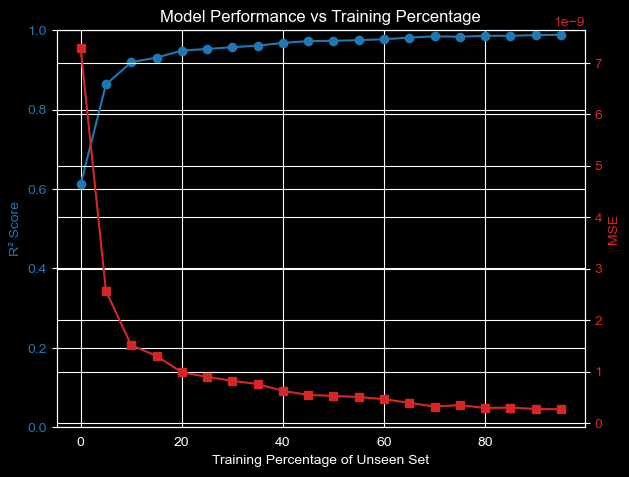

In [25]:
train_ids = ["00"]
test_ids = "01"
train_percentages = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
input_cols = train_features
output_col = "fcv1_i_mean"

df = dataset.df

results  = train_rf_with_unseen_percentages(df, train_ids, test_ids, train_percentages, input_cols, output_col, run_id_column='run_id')
plot_scores_vs_percentages(results, ylim1=(0, 1))

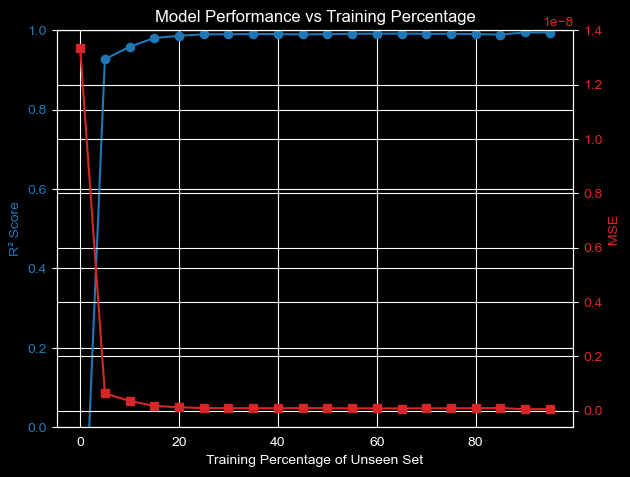

In [26]:
train_ids = ["00", "01"]
test_ids = "02"
train_percentages = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
input_cols = train_features
output_col = "fcv1_i_mean"

df = dataset.df

results  = train_rf_with_unseen_percentages(df, train_ids, test_ids, train_percentages, input_cols, output_col, run_id_column='run_id')
plot_scores_vs_percentages(results, ylim1=(0, 1))

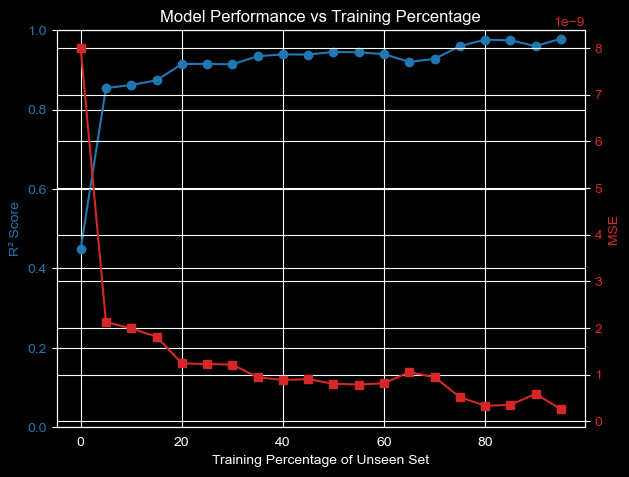

In [27]:
train_ids = ["00", "01", "02"]
test_ids = "03"
train_percentages = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
input_cols = train_features
output_col = "fcv1_i_mean"

df = dataset.df

results  = train_rf_with_unseen_percentages(df, train_ids, test_ids, train_percentages, input_cols, output_col, run_id_column='run_id')
plot_scores_vs_percentages(results, ylim1=(0, 1))

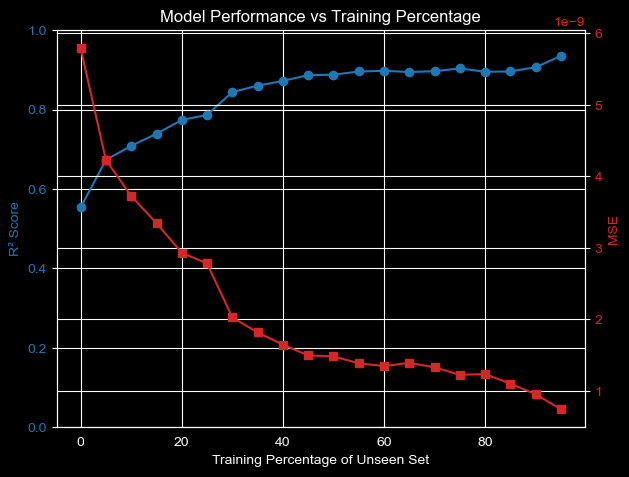

In [28]:
train_ids = ["00", "01", "02", "03", "04"]
test_ids = "05"
train_percentages = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
input_cols = train_features
output_col = "fcv1_i_mean"

df = dataset.df

results  = train_rf_with_unseen_percentages(df, train_ids, test_ids, train_percentages, input_cols, output_col, run_id_column='run_id')
plot_scores_vs_percentages(results, ylim1=(0, 1))

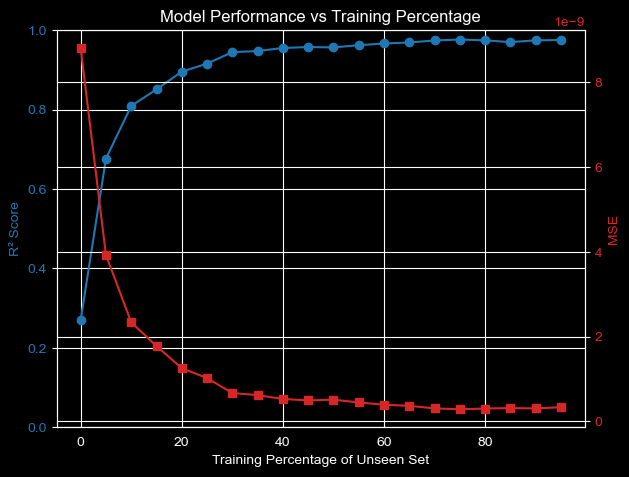

In [29]:
train_ids = ["00", "01", "02", "03", "04", "06", "08", "09", "10"]
test_ids = "11"
train_percentages = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
input_cols = train_features
output_col = "fcv1_i_mean"

df = dataset.df

results  = train_rf_with_unseen_percentages(df, train_ids, test_ids, train_percentages, input_cols, output_col, run_id_column='run_id')
plot_scores_vs_percentages(results, ylim1=(0, 1))

## Only using one run_id

In [115]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.utils import shuffle

def train_on_subsets(df, run_id, num_test_points, feature_columns, target_column, increment=50, random_state=42):
    """
    Trains and evaluates a Random Forest regressor on increasing subsets of training data.

    Parameters:
    - df (pd.DataFrame): The complete dataset containing features, target, and run_id columns.
    - run_id (str or int): The run_id to filter the dataset for training and testing.
    - num_test_points (int): Number of data points to include in the test set.
    - feature_columns (list): List of column names to be used as features.
    - target_column (str): The column name of the target variable.
    - increment (int, optional): Number of points to add to the training set in each iteration. Default is 50.
    - random_state (int, optional): Seed for reproducibility. Default is 42.

    Returns:
    - tuple: (training_sizes, r2_scores, mse_errors)
        - training_sizes (list): List of training set sizes used.
        - r2_scores (list): Corresponding list of R² scores for each training size.
        - mse_errors (list): Corresponding list of MSE values for each training size.
    """
    # Filter the dataframe for the specified run_id
    run_data = df[df['run_id'] == run_id]
    
    # Check if the dataset has enough points
    if len(run_data) < num_test_points + increment:
        raise ValueError(f"Not enough data points in run_id '{run_id}' for the specified number of test points and training increment.")
    
    # Shuffle the data
    run_data_shuffled = shuffle(run_data, random_state=random_state).reset_index(drop=True)
    
    # Split into test set and training pool
    test_set = run_data_shuffled.iloc[:num_test_points]
    training_pool = run_data_shuffled.iloc[num_test_points:]
    
    # Determine the maximum training set size
    max_training_size = len(training_pool)
    
    # Generate training sizes incrementally
    training_sizes = list(range(increment, max_training_size + 1, increment))
    
    # Ensure the full training pool is included
    if training_sizes[-1] != max_training_size:
        training_sizes.append(max_training_size)
    
    # Initialize lists to store results
    r2_scores = []
    mse_errors = []
    
    # Features and target for the test set
    X_test = test_set[feature_columns]
    y_test = test_set[target_column]
    
    for size in training_sizes:
        if size > max_training_size:
            continue  # Skip if size exceeds the training pool
        
        # Select the first 'size' points from the training pool
        training_subset = training_pool.iloc[:size]
        
        X_train = training_subset[feature_columns]
        y_train = training_subset[target_column]
        
        # Initialize and train the Random Forest Regressor
        regressor = RandomForestRegressor(random_state=random_state, n_jobs=-1)
        regressor.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = regressor.predict(X_test)
        
        # Calculate R² score and MSE
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        
        # Store the results
        r2_scores.append(r2)
        mse_errors.append(mse)
    
    return (training_sizes, r2_scores, mse_errors)


import matplotlib.pyplot as plt

def plot_training_performance(training_sizes, r2_scores, mse_errors, xlabel='Training Set Size', title='Model Performance vs Training Set Size'):
    """
    Plots R² scores and MSE errors against training set sizes on the same plot with twin y-axes.
    Utilizes a dark background and modern styling.
    Additionally, labels the minimum training set size that achieves an R² score of at least 0.9.
    
    Parameters:
    - training_sizes (list): List of training set sizes.
    - r2_scores (list): Corresponding list of R² scores.
    - mse_errors (list): Corresponding list of MSE values.
    - xlabel (str, optional): Label for the x-axis. Default is 'Training Set Size'.
    - title (str, optional): Title of the plot. Default is 'Model Performance vs Training Set Size'.
    """
    plt.style.use('dark_background')
    
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # Plot R² Score
    color1 = 'cyan'
    ax1.set_xlabel(xlabel, fontsize=14, color='white')
    ax1.set_ylabel('R² Score', color=color1, fontsize=14)
    r2_line, = ax1.plot(training_sizes, r2_scores, marker='o', color=color1, label='R² Score', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=12)
    ax1.tick_params(axis='x', colors='white', labelsize=12)
    ax1.spines['bottom'].set_color('white')
    ax1.spines['left'].set_color(color1)
    ax1.grid(True, color='gray', linestyle='--', linewidth=0.5)
    ax1.set_ylim(0, max(r2_scores) + 0.1)
    
    # Plot MSE on twin axis
    ax2 = ax1.twinx()
    color2 = 'magenta'
    ax2.set_ylabel('Mean Squared Error', color=color2, fontsize=14)
    mse_line, = ax2.plot(training_sizes, mse_errors, marker='s', color=color2, label='MSE', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=12)
    ax2.spines['right'].set_color(color2)
    ax2.set_ylim(0, max(mse_errors) * 1.2)
    
    # Set title
    plt.title(title, fontsize=16, color='white', pad=20)
    
    # Combine legends from both axes
    lines = [r2_line, mse_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=12)
    
    # Identify the minimum training size achieving R² >= 0.9
    min_size = None
    for size, r2 in zip(training_sizes, r2_scores):
        if r2 >= 0.9:
            min_size = size
            break
    
    # Add annotation below the plot
    if min_size is not None:
        annotation_text = f"Minimum Training Set Size for R² ≥ 0.9: {min_size} points"
    else:
        annotation_text = "R² Score of 0.9 not achieved with available training sizes."
    
    # Adjust layout to make space for the annotation
    plt.subplots_adjust(bottom=0.35)
    
    # Add the annotation
    fig.text(0.5, 0.05, annotation_text, ha='center', fontsize=14, color='white', bbox=dict(facecolor='gray', alpha=0.3, edgecolor='none'))
    
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()



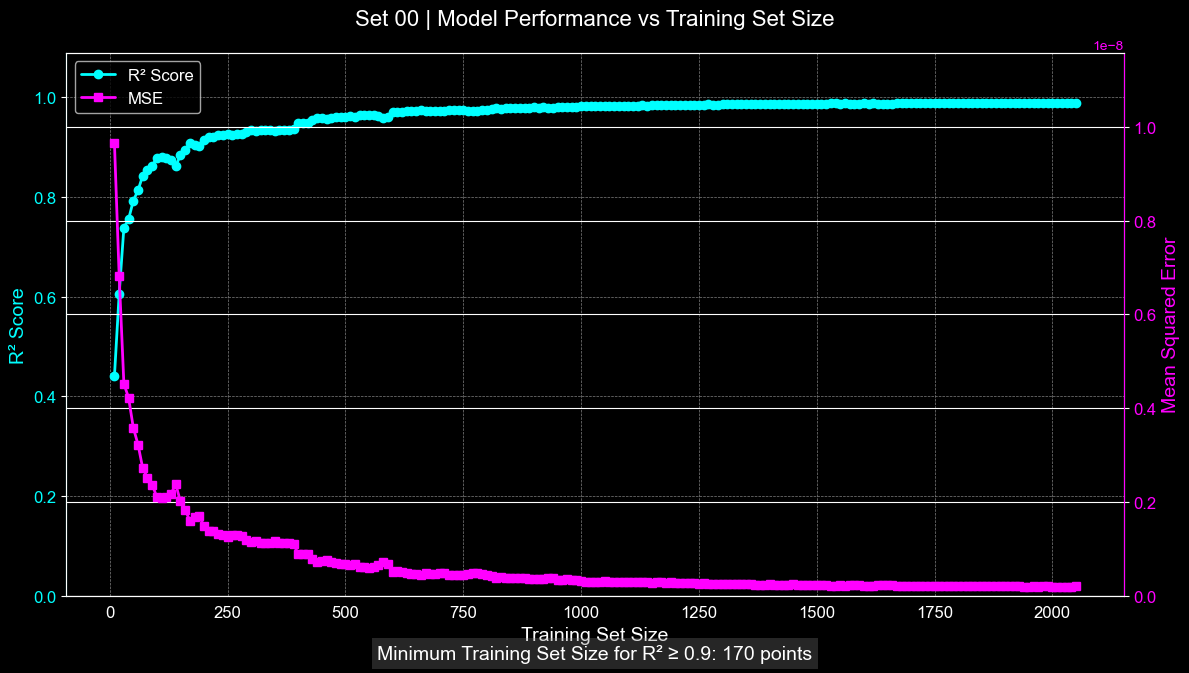

In [116]:
run_id = "00"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

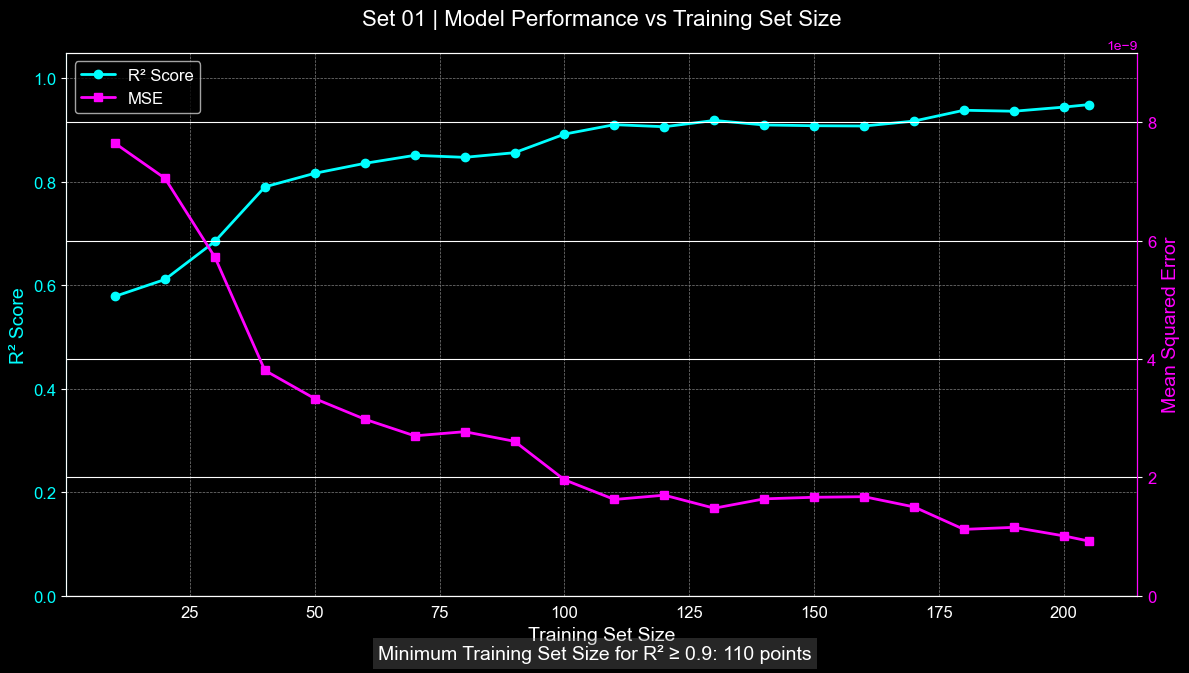

In [117]:
run_id = "01"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

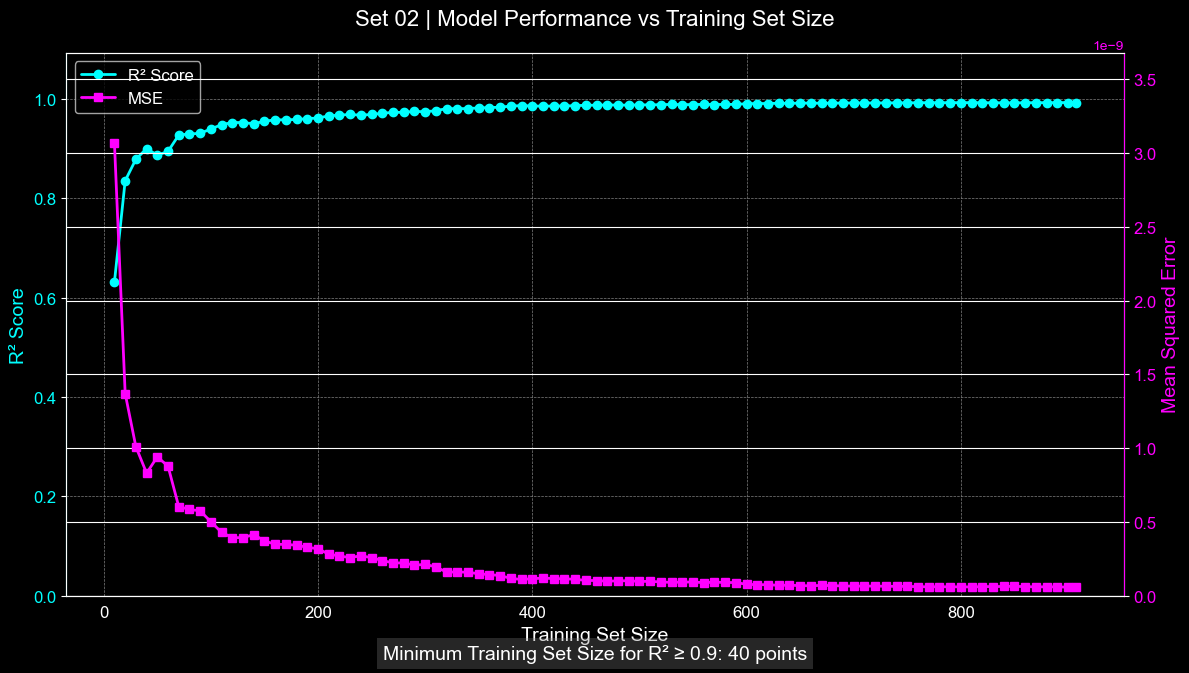

In [118]:
run_id = "02"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

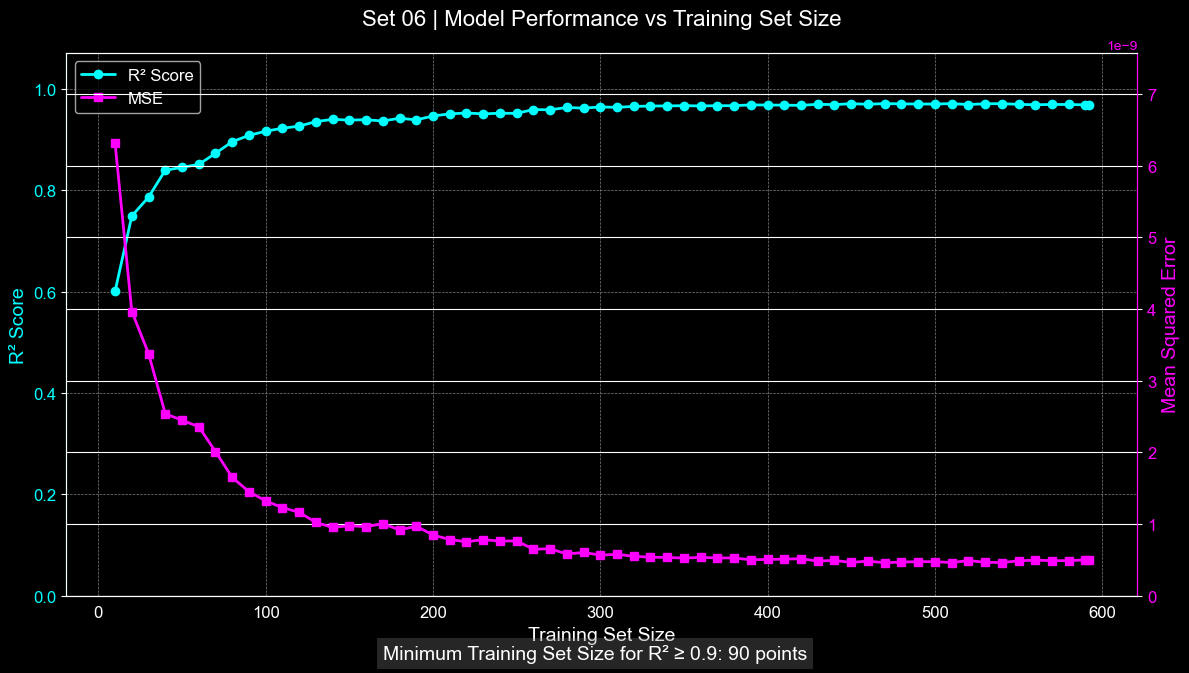

In [119]:
run_id = "06"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

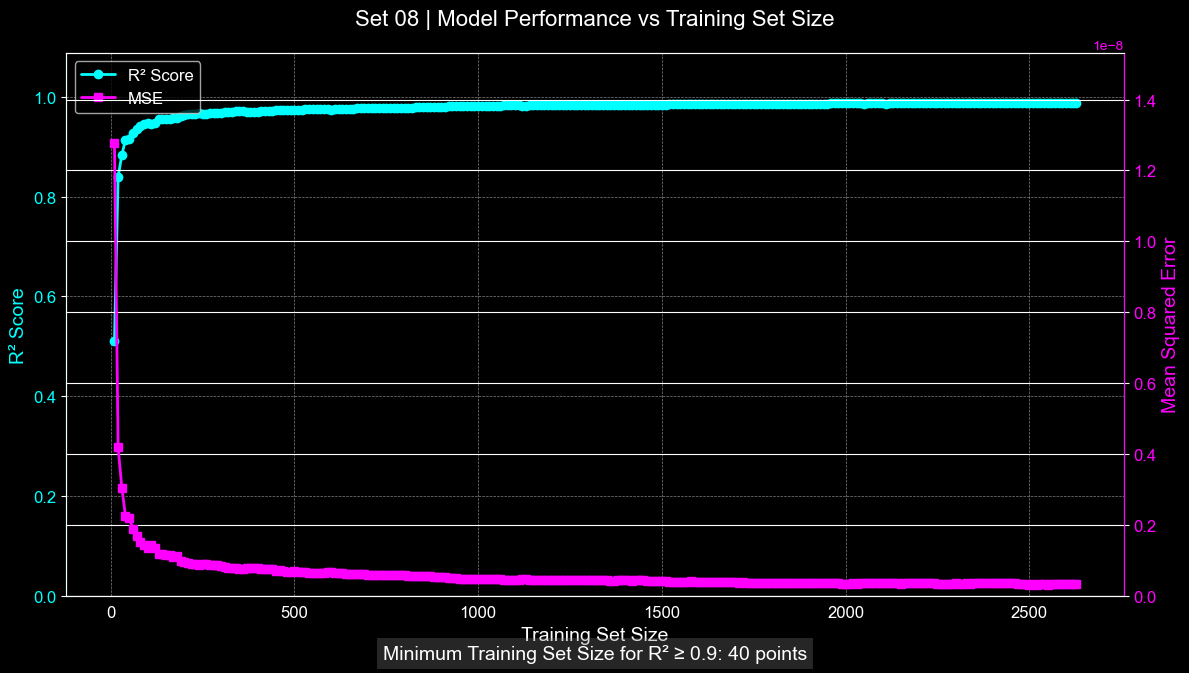

In [120]:
run_id = "08"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

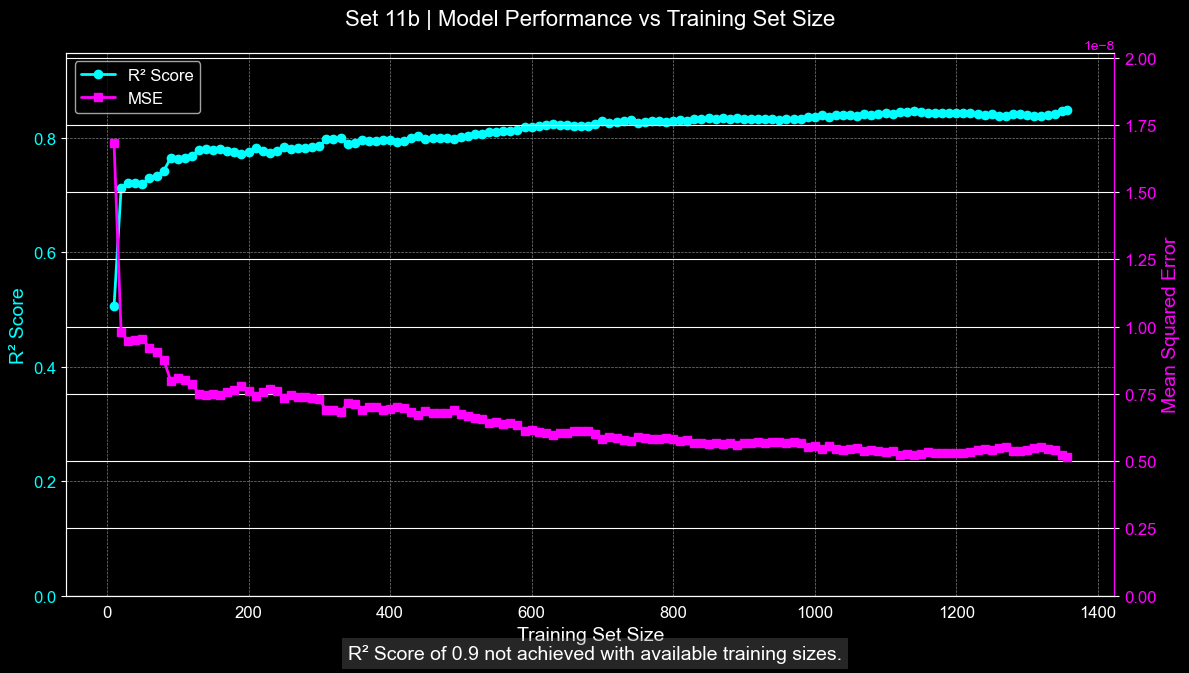

In [121]:
run_id = "11b"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

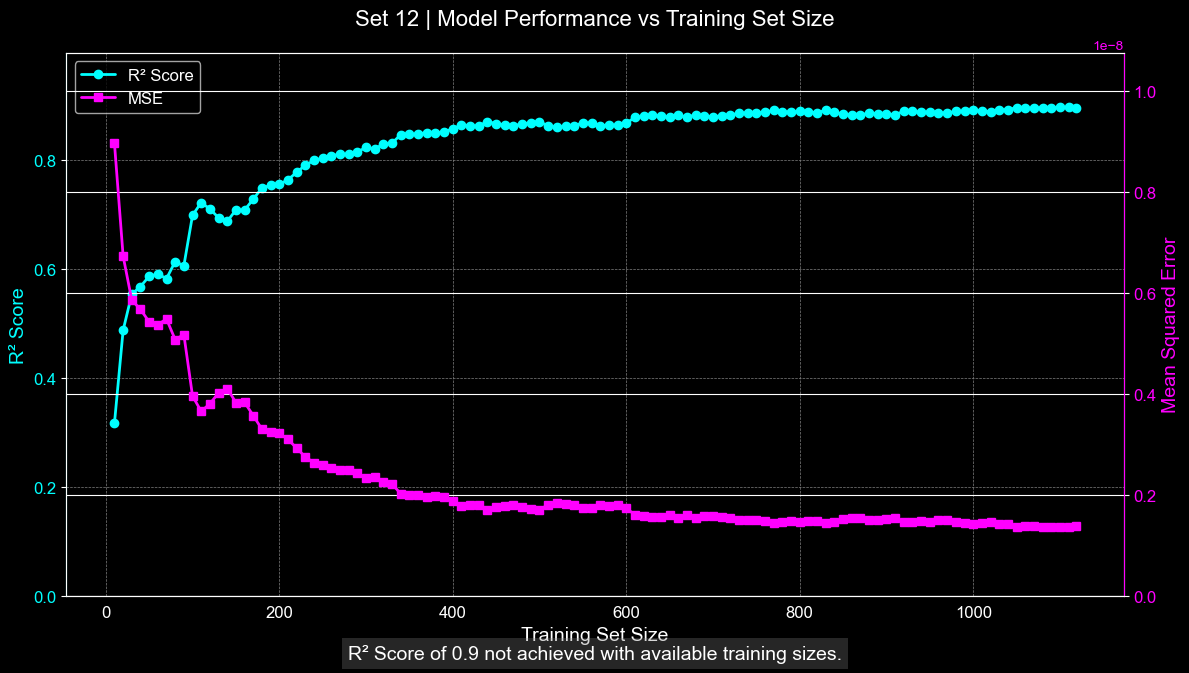

In [122]:
run_id = "12"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

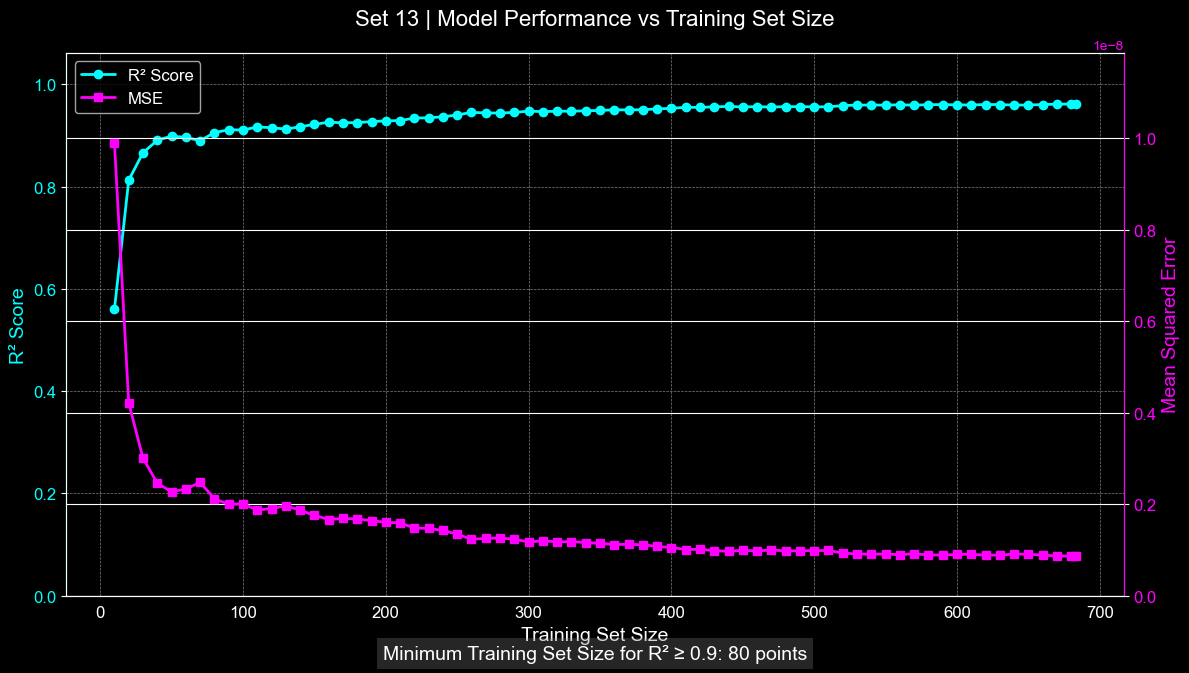

In [123]:
run_id = "13"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')

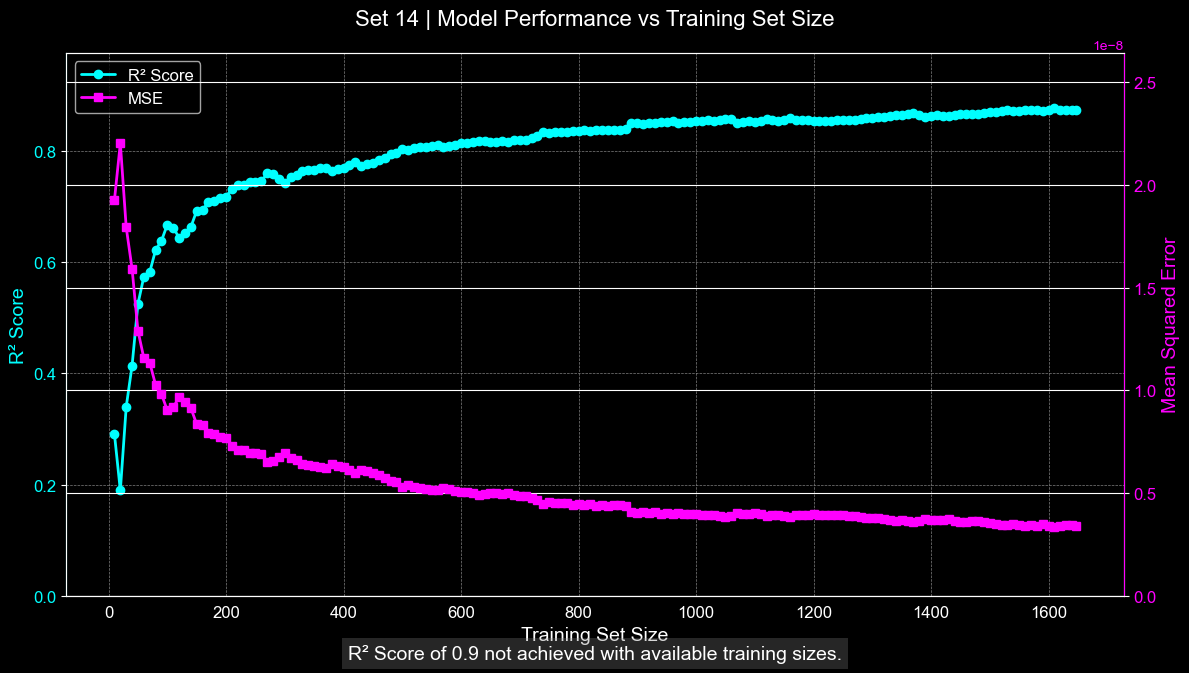

In [124]:
run_id = "14"
num_test_points = 500
feature_columns = train_features
target_column = "fcv1_i_mean"

training_sizes, r2_scores, mse_errors = train_on_subsets(
    df=df,
    run_id=run_id,
    num_test_points=num_test_points,
    feature_columns=feature_columns,
    target_column=target_column,
    increment=10,
    random_state=88
)

plot_training_performance(training_sizes, r2_scores, mse_errors, title=f'Set {run_id} | Model Performance vs Training Set Size')